# Comparison: Markowitz vs AI-Gated Markowitz vs Full (AI+Graph+Markowitz)

Notebook ini membandingkan tiga strategi utama untuk mengevaluasi kontribusi komponen AI Gatekeeper dan Graph Filter:
1. **Markowitz Saja (Baseline)**: Optimasi Mean-Variance standar setiap hari menggunakan seluruh aset.
2. **Markowitz with AI Gatekeeper**: Menggunakan AI (Random Forest) untuk deteksi resim. Jika Bearish, pindah ke Cash. Jika Bullish, Markowitz pada *seluruh* aset.
3. **Full (AI + Graph + Markowitz)**: Strategi lengkap. Jika Bullish, filter aset dengan Graph Theory (MIS) sebelum optimasi Markowitz.
4. **Benchmark (BTC)**: Buy and hold Bitcoin.

In [13]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import os

# Config
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Load Data
file_path = 'dataset_2023_2025.xlsx'
if os.path.exists(file_path):
    data = pd.read_excel(file_path, index_col=0, parse_dates=True)
    print(f"Loaded {len(data)} rows of data.")
else:
    print("File data tidak ditemukan! Harap jalankan notebook original untuk mendownload data.")

Loaded 990 rows of data.


## 1. Feature Engineering & AI Training
Melatih AI Gatekeeper menggunakan data 2023-2024.

In [14]:
# Returns
returns = data.pct_change().dropna()
market_return = returns.mean(axis=1)

# Features
features = pd.DataFrame(index=returns.index)
features['Vol_20'] = market_return.rolling(window=20).std()
features['Mom_20'] = market_return.rolling(window=20).mean()
features['Mom_50'] = market_return.rolling(window=50).mean()
features['Target'] = (market_return.shift(-1) > 0).astype(int)
features = features.dropna()

# Split
train_mask = (features.index.year >= 2023) & (features.index.year <= 2024)
test_mask = (features.index.year == 2025)
X_train, y_train = features.loc[train_mask, ['Vol_20', 'Mom_20', 'Mom_50']], features.loc[train_mask, 'Target']
X_test, y_test = features.loc[test_mask, ['Vol_20', 'Mom_20', 'Mom_50']], features.loc[test_mask, 'Target']

# Train RF
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, min_samples_split=10)
rf_model.fit(X_train, y_train)
test_probs = pd.Series(rf_model.predict_proba(X_test)[:, 1], index=X_test.index)

## 2. Helper Functions

In [15]:
def get_mis_assets(returns_window, correlation_threshold=0.5):
    corr_mat = returns_window.corr()
    G = nx.Graph()
    assets = returns_window.columns
    G.add_nodes_from(assets)
    for i in range(len(assets)):
        for j in range(i+1, len(assets)):
            if corr_mat.iloc[i, j] > correlation_threshold:
                G.add_edge(assets[i], assets[j])
    mis = nx.approximation.maximum_independent_set(G)
    return list(mis)

def optimize_markowitz(selected_assets_returns):
    if len(selected_assets_returns.columns) == 0: return {}
    if len(selected_assets_returns.columns) == 1: return {selected_assets_returns.columns[0]: 1.0}
        
    mu = selected_assets_returns.mean() * 252
    sigma = selected_assets_returns.cov() * 252
    
    def neg_sharpe_ratio(weights):
        port_return = np.sum(weights * mu)
        port_volatility = np.sqrt(np.dot(weights.T, np.dot(sigma, weights)))
        return -port_return / port_volatility if port_volatility > 0 else 0
    
    constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
    bounds = tuple((0, 1) for _ in range(len(mu)))
    initial_guess = len(mu) * [1. / len(mu)]
    
    try:
        result = minimize(neg_sharpe_ratio, initial_guess, method='SLSQP', bounds=bounds, constraints=constraints)
        return dict(zip(selected_assets_returns.columns, result.x))
    except:
        return dict(zip(selected_assets_returns.columns, initial_guess))

## 3. Backtest Engines

In [16]:
def run_simulation(strategy_type, test_dates, returns, probs, lookback=30, corr_threshold=0.5):
    current_value = 10000.0
    history = [current_value]
    dates = [test_dates[0]]
    
    for i, date in enumerate(test_dates[:-1]):
        is_bull = probs.loc[date] > 0.5 if strategy_type != 'Markowitz Only' else True
        
        loc_idx = returns.index.get_loc(date)
        if loc_idx < lookback:
            weights = {t: 1.0/len(returns.columns) for t in returns.columns}
        else:
            window_returns = returns.iloc[loc_idx-lookback:loc_idx]
            
            if not is_bull:
                weights = {'CASH': 1.0}
            else:
                if strategy_type == 'Full':
                    selected_assets = get_mis_assets(window_returns, corr_threshold)
                    weights = optimize_markowitz(window_returns[selected_assets])
                else:
                    # Markowitz on all assets
                    weights = optimize_markowitz(window_returns)
        
        # Next day return
        next_date = test_dates[i+1]
        next_day_rets = returns.loc[next_date]
        
        daily_ret = 0
        if 'CASH' in weights:
            daily_ret = 0
        else:
            for asset, w in weights.items():
                daily_ret += w * next_day_rets[asset]
        
        current_value *= (1 + daily_ret)
        history.append(current_value)
        dates.append(next_date)
        
    return pd.Series(history, index=dates)

## 4. Execution

In [17]:
test_dates = X_test.index
print("Running Markowitz Only...")
res_markowitz = run_simulation('Markowitz Only', test_dates, returns, test_probs)
print("Running AI-Gated Markowitz...")
res_ai_gated = run_simulation('AI-Gated Markowitz', test_dates, returns, test_probs)
print("Running Full (AI+Graph+Markowitz)...")
res_full = run_simulation('Full', test_dates, returns, test_probs)

# Benchmark BTC
btc_series = data.loc[test_dates, 'BTC-USD']
btc_norm = btc_series / btc_series.iloc[0] * 10000

Running Markowitz Only...
Running AI-Gated Markowitz...
Running Full (AI+Graph+Markowitz)...


## 5. Result Visualization & Performance Metrics

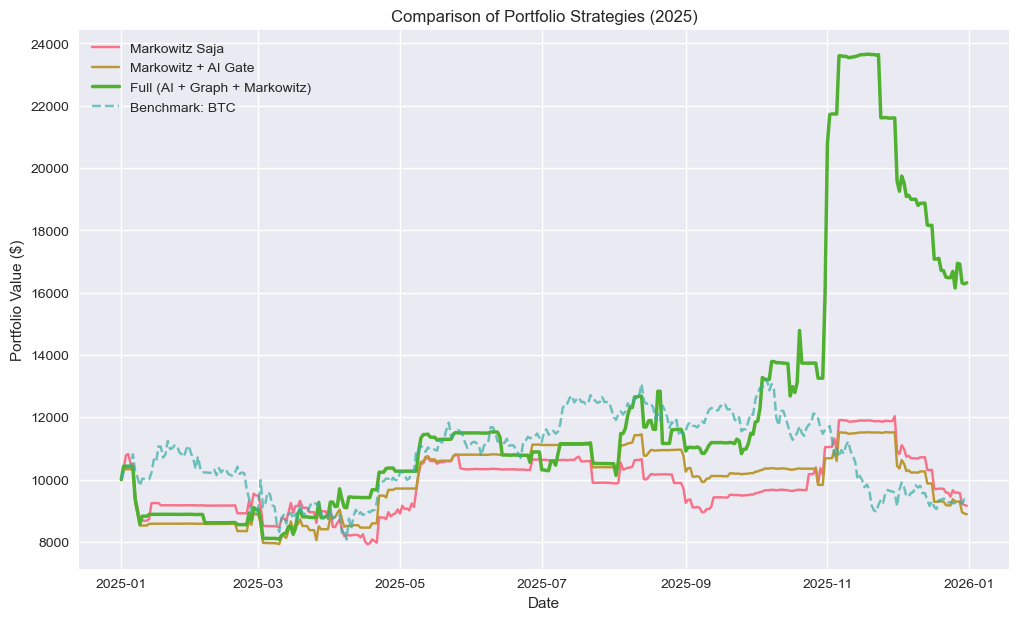

,Strategy,Total Return (%),Sharpe Ratio,Max Drawdown (%)
0,Markowitz Saja,-8.398380,-0.037106,-26.759189
1,Markowitz + AI Gate,-11.128424,-0.153705,-23.262079
2,Full (AI + Graph),63.180759,0.927839,-31.737035
3,Benchmark: BTC,-7.319368,0.022806,-32.146980


In [18]:
plt.figure(figsize=(12, 7))
plt.plot(res_markowitz, label='Markowitz Saja')
plt.plot(res_ai_gated, label='Markowitz + AI Gate')
plt.plot(res_full, label='Full (AI + Graph + Markowitz)', linewidth=2.5)
plt.plot(btc_norm, label='Benchmark: BTC', linestyle='--', alpha=0.7)
plt.title("Comparison of Portfolio Strategies (2025)")
plt.xlabel("Date")
plt.ylabel("Portfolio Value ($)")
plt.legend()
plt.show()

def calc_metrics(series, name):
    ret = series.pct_change().dropna()
    total_return = (series.iloc[-1] / series.iloc[0] - 1) * 100
    sharpe = (ret.mean() / ret.std()) * np.sqrt(252)
    drawdown = (series / series.cummax() - 1).min() * 100
    return {'Strategy': name, 'Total Return (%)': total_return, 'Sharpe Ratio': sharpe, 'Max Drawdown (%)': drawdown}

metrics = [
    calc_metrics(res_markowitz, 'Markowitz Saja'),
    calc_metrics(res_ai_gated, 'Markowitz + AI Gate'),
    calc_metrics(res_full, 'Full (AI + Graph)'),
    calc_metrics(btc_norm, 'Benchmark: BTC')
]

df_metrics = pd.DataFrame(metrics)
display(df_metrics)